In [1]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.0 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 20.7 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/36.5 MB 25.1 MB/s eta 0:00:02
   ---------- ----------------------------- 9.7/36.5 MB 24.1 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/36.5 MB 22.5 MB/s eta 0:00:02
   ------------------- -------------------- 17.8/36.5 MB 21.6 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/36.5 MB 21.6 MB/s eta 0:00:01
   ----------------------------- ---------- 26.7/36.5 MB

In [3]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [7]:
merge_cols = [col for col in data_mat.columns if col not in ["G1", "G2", "G3", "absences"]]

data=pd.merge(data_mat, data_por, on=merge_cols, how="outer", suffixes=("_mat", "_por"))
data.head()


,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,Walc,health,absences_mat,G1_mat,G2_mat,G3_mat,absences_por,G1_por,G2_por,G3_por
0,F,15,R,GT3,T,1,1,at_home,at_home,course,...,2,2,NaN,NaN,NaN,NaN,0.0,13.0,14.0,14.0
1,F,15,R,GT3,T,1,1,at_home,other,home,...,1,2,NaN,NaN,NaN,NaN,1.0,11.0,10.0,11.0
2,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,NaN,NaN,NaN,NaN,4.0,13.0,13.0,13.0
3,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,2.0,7.0,10.0,10.0,NaN,NaN,NaN,NaN
4,F,15,R,GT3,T,1,1,at_home,services,other,...,1,2,NaN,NaN,NaN,NaN,6.0,10.0,10.0,10.0


In [59]:
print(data.columns)


Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences_mat', 'G1_mat', 'G2_mat', 'G3_mat', 'absences_por',
       'G1_por', 'G2_por', 'G3_por'],
      dtype='str')


In [5]:
label = ['course', 'other', 'home', 'reputation']
prop=[data_mat[(data_mat["reason"] == name)]["studytime"].count()/len(data_mat) for name in label]

label_por = ['course', 'other', 'home', 'reputation']
prop_por=[data_por[(data_por["reason"] == name)]["studytime"].count()/len(data_por) for name in label]



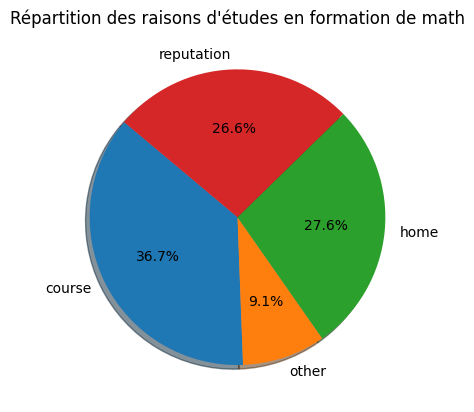

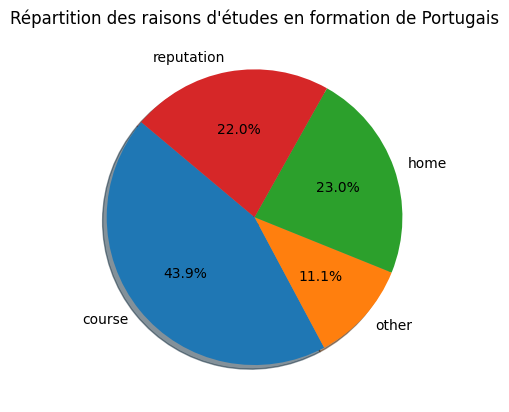

"\nCes graphiques représentent les différentes raisons d'intégration des études avec 'home' signifiant la proximité de l'établissement au domicile.\nOn remarque qu'une majorité des étudiants choississent leurs études en fonction des cours dispensés, suivis de facon équivalente par la réputation et la proximité.\nOn peut alors se demander si cela impacte leurs sérieux, résultats et consommations d'alcool par la suite. \n"

In [6]:
plt.pie(prop, labels=label,autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Répartition des raisons d'études en formation de math")
plt.show()

plt.pie(prop_por, labels=label_por,autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Répartition des raisons d'études en formation de Portugais")
plt.show()

"""
Ces graphiques représentent les différentes raisons d'intégration des études avec 'home' signifiant la proximité de l'établissement au domicile.
On remarque qu'une majorité des étudiants choississent leurs études en fonction des cours dispensés, suivis de facon équivalente par la réputation et la proximité.
On peut alors se demander si cela impacte leurs sérieux, résultats et consommations d'alcool par la suite. 
"""



In [7]:
meanG = (data_mat["G3"]+data_mat["G2"]+data_mat["G1"])/3
meanG
data_mat["meanG"] = meanG
data_mat.head()

meanG = (data_por["G3"]+data_por["G2"]+data_por["G1"])/3
meanG
data_por["meanG"] = meanG
data_por.head()
#Moyennes des notes dans l'année. 

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,meanG
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,3,4,1,1,3,4,0,11,11,7.333333
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,3,3,1,1,3,2,9,11,11,10.333333
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,3,2,2,3,3,6,12,13,12,12.333333
GP,F,15,U,GT3,T,4,2,health,services,home,...,2,2,1,1,5,0,14,14,14,14.000000
GP,F,16,U,GT3,T,3,3,other,other,home,...,3,2,1,2,5,0,11,13,13,12.333333


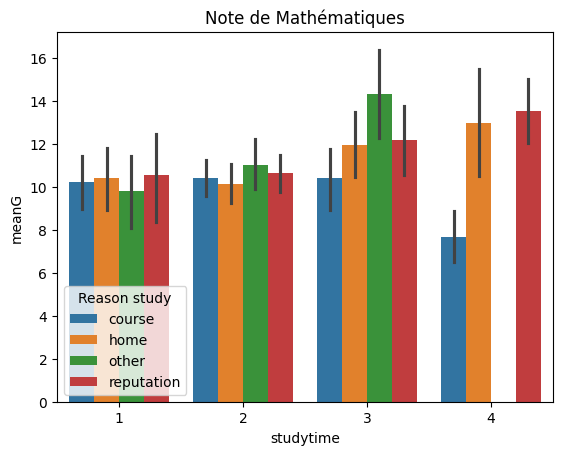

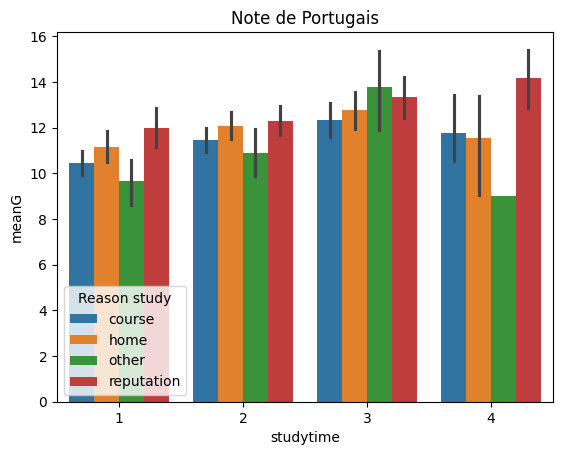

In [8]:
fig = plt.figure()
ax = sns.barplot(data_mat, x="studytime", y="meanG", estimator=np.mean, hue = "reason")
ax.title.set_text("Note de Mathématiques")
ax.legend(loc="lower left", title="Reason study")

fig = plt.figure()
ax = sns.barplot(data_por, x="studytime", y="meanG", estimator=np.mean, hue = "reason")
ax.title.set_text("Note de Portugais")

ax.legend(loc="lower left", title="Reason study")
"""
Sur le premier graphique, on remarque une évolution notoire des moyennes des élèves en fonction de leur temps d'étude principalement pour ceux ayant choisie leurs écoles pour leurs proximités, leur réputations ou d'autres raisons. 
Cependant, les élèves ayant choisie leurs écoles pour les cours n'ont pas d'évolution en fonction de leurs temps d'étude mais une baisse !
Il en va de même pour les élèves de portugais (second graphique) sauf pour la 4 heures d'étude dans laquelle la baisse des notes est présente qu'importe leurs raisons d'étude.


"""

"\nCe graphique permet de nuancer les précendants en représentant la répartition non égalitaire des raisons d'études parmis les étudiants.\nEn effet, ceux travaillant 2h par semaines sont les plus majoritaires et ceux travaillant 3 et 4h sont beaucoup moins présents.\nCependant, on peut également remarquer que la consommation d'alcool semble homogén\n"

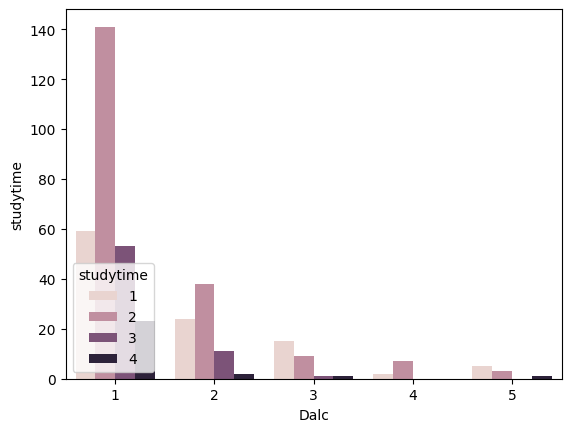

In [10]:
fig = plt.figure()

ax = sns.barplot(data=data_mat, x="Dalc", y="studytime", estimator=np.count_nonzero, hue="studytime")

ax.legend(loc="lower left", title="studytime")

"""
Ce graphique permet de nuancer les précendants en représentant la répartition non égalitaire des raisons d'études parmis les étudiants.
En effet, ceux travaillant 2h par semaines sont les plus majoritaires et ceux travaillant 3 et 4h sont beaucoup moins présents.
On peut également remarquer la baisse du nombre d'étudiants consommant de plus en plus d'alcool. 
"""

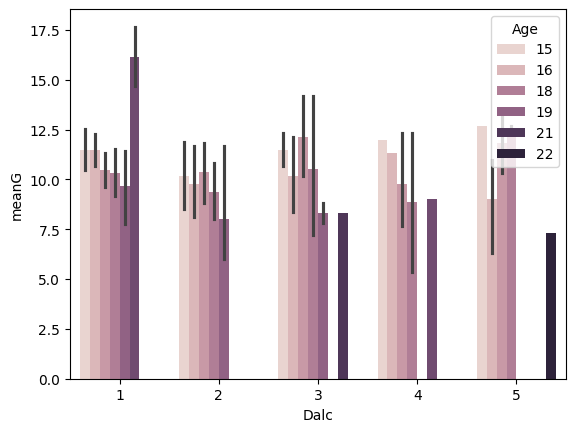

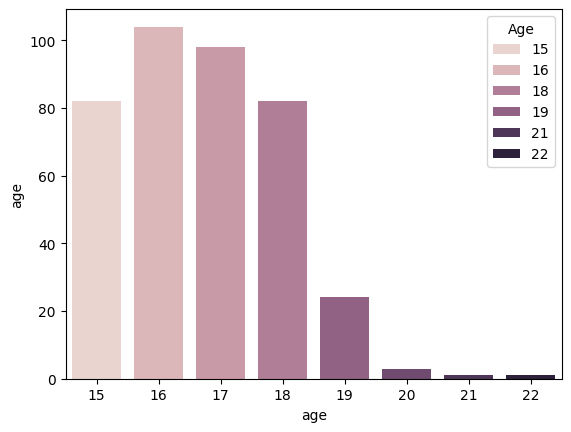

In [11]:
fig = plt.figure()

ax = sns.barplot(data_mat, x="Dalc", y="meanG", estimator=np.mean, hue = "age")

ax.legend(loc="upper right", title="Age")

fig = plt.figure()

ax = sns.barplot(data_mat, x="Walc", y="Walc", estimator=np.count_nonzero, hue = "age")

ax.legend(loc="upper right", title="Age")


fig = plt.figure()

ax = sns.barplot(data_mat, x="age", y="age", estimator=np.count_nonzero, hue = "age")

ax.legend(loc="upper right", title="Age")

"""
Ce barplot nous permet de constater que les élèves plus agé réussissent de moins en moins plus ils consomment de l'alcool, cependant le second graphique nous montre que nous disposons de très peu d'élèves ayant 20 ans ou plus, ce qui rend toutes analyses biaisées.


"""

In [10]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn import tree


In [6]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime"]]

In [7]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime"]]

In [26]:
    
from sklearn.tree import DecisionTreeRegressor
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model_0 = DecisionTreeRegressor()
model_1 = SGDClassifier()
model_2 = DecisionTreeClassifier()
model_3 = KNeighborsClassifier(n_neighbors=2)

model_4 = VotingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('KNN', model_3)],
                          voting='hard')

for model in (model_0, model_1, model_2, model_3, model_4):
    model.fit(X_train, y_train)
    print(model.__class__.__name__, model.score(X_test, y_test))
     



DecisionTreeRegressor -0.7977055883689224
SGDClassifier 0.4117647058823529
DecisionTreeClassifier 0.5798319327731093
KNeighborsClassifier 0.6722689075630253
VotingClassifier 0.7310924369747899


[Text(0.502939142461964, 0.9722222222222222, 'x[8] <= 1.5\ngini = 0.496\nsamples = 276\nvalue = [187, 54, 21, 7, 7]'),
 Text(0.22959889349930843, 0.9166666666666666, 'x[4] <= 3.5\ngini = 0.652\nsamples = 72\nvalue = [36, 18, 13, 1, 4]'),
 Text(0.3662690179806362, 0.9444444444444444, 'True  '),
 Text(0.1355463347164592, 0.8611111111111112, 'x[7] <= 17.5\ngini = 0.518\nsamples = 43\nvalue = [28.0, 9.0, 5.0, 1.0, 0.0]'),
 Text(0.06639004149377593, 0.8055555555555556, 'x[5] <= 4.5\ngini = 0.395\nsamples = 33\nvalue = [25, 5, 3, 0, 0]'),
 Text(0.027662517289073305, 0.75, 'x[6] <= 9.0\ngini = 0.133\nsamples = 14\nvalue = [13, 0, 1, 0, 0]'),
 Text(0.016597510373443983, 0.6944444444444444, 'gini = 0.0\nsamples = 10\nvalue = [10, 0, 0, 0, 0]'),
 Text(0.03872752420470263, 0.6944444444444444, 'x[6] <= 11.0\ngini = 0.375\nsamples = 4\nvalue = [3, 0, 1, 0, 0]'),
 Text(0.027662517289073305, 0.6388888888888888, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0]'),
 Text(0.04979253112033195, 0.63888888

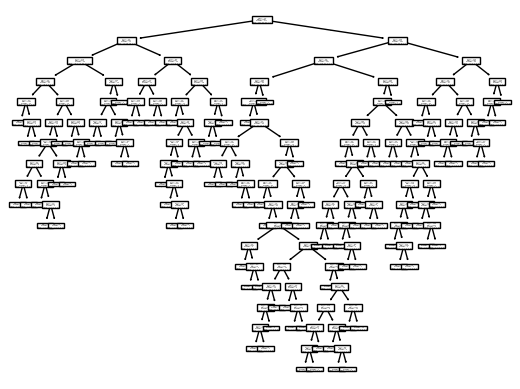

In [9]:
tree.plot_tree(model_2)

In [27]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [72]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)


model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6722689075630253

In [29]:
model = RandomForestClassifier(n_estimators=100, max_depth=3)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [30]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [ ]:
best = 0
best_k=0
for k in range (1,100,1):
    model = AdaBoostClassifier(n_estimators=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    if(best<score):
        best=score
        best_k=k
    if(score>0.73):
        print(k,score)

1 0.7478991596638656
2 0.7478991596638656
3 0.7478991596638656
4 0.7478991596638656
6 0.7478991596638656
7 0.7310924369747899
8 0.7310924369747899
9 0.7310924369747899
10 0.7478991596638656
11 0.7478991596638656
12 0.7478991596638656
18 0.7478991596638656
19 0.7478991596638656
20 0.7394957983193278
23 0.7394957983193278
24 0.7394957983193278
25 0.7394957983193278
27 0.7478991596638656
31 0.7478991596638656


In [62]:
model = AdaBoostClassifier(n_estimators=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.7478991596638656

In [42]:
print(best_k,best)

1 0.7478991596638656


In [43]:
from sklearn.ensemble import StackingClassifier

In [69]:
model = StackingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('KNN', model_3)],
                             final_estimator=DecisionTreeClassifier())

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.5042016806722689